In [2]:
import os
import re
import cv2
import glob
import numpy as np
from matplotlib import cm
import matplotlib.pyplot as plt

In [4]:
def natural_sort_key(s):
    """
    Sort strings containing numbers naturally (e.g., frame1.npy, frame2.npy, ..., frame10.npy)
    """
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]


def recover_class_labels(overlay, img_to_viz, num_of_labels, alpha=0.5, cmap=None, return_viz=False):
    """
    Invert multiclass_vis:
      overlay = alpha * cmap(class_labels/num_of_labels)[..., :3] + (1 - alpha) * (img_to_viz/255)

    Args:
        overlay: HxWx3 float in [0,1] or uint8 in [0,255] (the function's returned _overlay).
        img_to_viz: HxWx3 uint8 original image used in multiclass_vis.
        num_of_labels: number of classes (K).
        alpha: blend factor used originally.
        cmap: matplotlib colormap; if None, uses 'viridis' (must match what was used originally).
        return_viz: if True, also return the recovered colormap image (viz_est).

    Returns:
        class_labels: HxW int array with values in [0, K-1].
        (optional) viz_est: HxWx3 float in [0,1], the recovered colormap RGB per pixel.
    """
    if cmap is None:
        cmap = cm.get_cmap('viridis')


    # Ensure float32 in [0,1]
    over = overlay.astype(np.float32)
    if over.max() > 1.0:
        over /= 255.0
    base = img_to_viz.astype(np.float32) / 255.0

    eps = 1e-8
    if alpha <= eps:
        raise ValueError("alpha must be > 0 to invert the blend.")

    # Recover the colormap image that was blended in
    viz_est = (over - (1.0 - alpha) * base) / alpha
    viz_est = np.clip(viz_est, 0.0, 1.0)

    # Build the discrete palette used by cmap(class_labels/num_of_labels)
    t = (np.arange(num_of_labels, dtype=np.float32) / float(num_of_labels))
    palette = cmap(t)[..., :3].astype(np.float32)  # Kx3, RGB

    # Assign each pixel to nearest palette color (Euclidean in RGB)
    H, W, _ = viz_est.shape
    v = viz_est.reshape(-1, 3)                        # (N,3)
    # (N,K,3) -> (N,K)
    d2 = ((v[:, None, :] - palette[None, :, :]) ** 2).sum(axis=2)
    labels = d2.argmin(axis=1).astype(np.int32).reshape(H, W)

    if return_viz:
        return labels, viz_est
    return labels


## Create Centroids Array

In [5]:
import cv2
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

dir = '/home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/'
output_path = f"{dir}/tracker_data.npz"
image_folder = dir + 'Stream_tracking/'
overlay_folder = dir + 'Tracker-result/'
plot_folder = dir + 'Tracking-plots/'

# Create folder for plots if it doesn't exist
os.makedirs(plot_folder, exist_ok=True)

image_files = glob.glob(os.path.join(image_folder, f"*.jpg"))
overlay_files = glob.glob(os.path.join(overlay_folder, f"*.jpg"))

centroids = []
origins = []
offsets = []

image_files.sort(key=natural_sort_key)
overlay_files.sort(key=natural_sort_key)

num_frames = len(image_files)
print(f"Processing {num_frames} frames...")

for i in range(num_frames):
    overlay_img = plt.imread(overlay_files[i])
    original_img = plt.imread(image_files[i])
    
    num_of_labels = 2
    alpha = 0.5
    class_labels = recover_class_labels(overlay_img, original_img, num_of_labels, alpha=alpha)
    
    target_pixels = np.where(class_labels == 1)
    
    if len(target_pixels[0]) == 0:
        print(f"Warning: No target found in frame {i}")
        # fig, ax = plt.subplots(1, 1, figsize=(12, 8))
        # ax.imshow(original_img)
        # plt.title("Object Tracking: Target Position")
        # plt.xlabel("X (pixels)")
        # plt.ylabel("Y (pixels)")
        # # plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
        # plt.tight_layout()
        # # Save plot
        # plot_filename = os.path.join(plot_folder, f"tracking_plot_{i:04d}.png")
        # plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
        # plt.close(fig)  # Close figure to free memory
        centroids.append([np.nan, np.nan])
        offsets.append(np.nan)
        origins.append([np.nan, np.nan])
        continue
    
    centroid_y = int(np.mean(target_pixels[0]))
    centroid_x = int(np.mean(target_pixels[1]))
    
    height, width = original_img.shape[:2]
    origin_y = height // 2
    origin_x = width // 2
    
    distance = np.sqrt((centroid_x - origin_x)**2 + (centroid_y - origin_y)**2)
    print(f"Frame {i}: Distance from origin: {distance:.2f} pixels")
    
    offsets.append(distance)
    centroids.append([centroid_x, centroid_y])
    origins.append([origin_x, origin_y])
    
    # # Create and save plot
    # fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    # ax.imshow(original_img)
    
    # # Plot image center (blue X)
    # ax.plot(origin_x, origin_y, 'bx', markersize=20,
    #         markeredgewidth=3, label='Image Center')
    
    # # Plot target centroid (red circle)
    # ax.plot(centroid_x, centroid_y, 'ro', markersize=15,
    #         markeredgewidth=2, markeredgecolor='white', label='Target Centroid')
    
    # # Draw line connecting them
    # ax.plot([origin_x, centroid_x], [origin_y, centroid_y],
    #         'r--', linewidth=2, alpha=0.7, label=f'Offset: {distance:.1f}px')
    
    # plt.title("Object Tracking: Target Position")
    # plt.xlabel("X (pixels)")
    # plt.ylabel("Y (pixels)")
    # plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
    # plt.tight_layout()
    
    # # Save plot
    # plot_filename = os.path.join(plot_folder, f"tracking_plot_{i:04d}.png")
    # plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
    # plt.close(fig)  # Close figure to free memory

centroids = np.array(centroids)
origins = np.array(origins)
offsets = np.array(offsets)

data = {
    'centroids': centroids,
    'origins': origins,
    'offsets': offsets,
}

np.savez_compressed(output_path, **data)

print(f"\nData saved to: {output_path}")
print(f"Plots saved to: {plot_folder}")
print(f"Total frames processed: {len(centroids)}")
print(f"Average offset: {np.mean(offsets):.2f} pixels")

Processing 1359 frames...
Frame 0: Distance from origin: 52.17 pixels
Frame 1: Distance from origin: 47.80 pixels
Frame 2: Distance from origin: 51.87 pixels
Frame 3: Distance from origin: 53.14 pixels
Frame 4: Distance from origin: 55.36 pixels
Frame 5: Distance from origin: 61.68 pixels
Frame 6: Distance from origin: 66.22 pixels
Frame 7: Distance from origin: 69.26 pixels
Frame 8: Distance from origin: 74.06 pixels
Frame 9: Distance from origin: 76.03 pixels
Frame 10: Distance from origin: 80.31 pixels
Frame 11: Distance from origin: 89.20 pixels
Frame 12: Distance from origin: 109.64 pixels
Frame 13: Distance from origin: 139.18 pixels
Frame 14: Distance from origin: 155.00 pixels
Frame 15: Distance from origin: 150.07 pixels
Frame 16: Distance from origin: 136.01 pixels
Frame 17: Distance from origin: 125.16 pixels
Frame 18: Distance from origin: 128.27 pixels
Frame 19: Distance from origin: 139.32 pixels
Frame 20: Distance from origin: 140.94 pixels
Frame 21: Distance from origin

## Error over time for turtle track

In [15]:
plot_dir = '/home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/'
timestamps_file = '/home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/elapsed_times.txt'
# for tetherless C, the timestamps file is timestamps_C.txt which include the damaged frames (therefore total count is 1450 vs actual 1336 frames saved)
data = np.genfromtxt(timestamps_file, delimiter='\n')

file_path = '/home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/tracker_data.npz'
npz_file = np.load(file_path, allow_pickle=True)
keys = list(npz_file.keys())
print(f"Keys found: {keys}")
for key in keys:
    print(f"{key} has shape: {npz_file[key].shape}")


Keys found: ['centroids', 'origins', 'offsets']
centroids has shape: (1359, 2)
origins has shape: (1359, 2)
offsets has shape: (1359,)


In [16]:
# Get the data
t_data = data
offsets_data = npz_file['offsets']

print(f"timestamps shape: {t_data.shape}")
print(f"error shape: {offsets_data.shape}")
    
# Define range to plot
start_idx = 350
end_idx = 650

x = t_data[start_idx:end_idx]
x_label = 'Time (seconds)'


fig, ax = plt.subplots(figsize=(12, 7))

# Plot both q and dqd on same axis
ax.plot(x, offsets_data[start_idx:end_idx], 'b-', label=f'Offset from origin (Pixels)', linewidth=1.5)

# Add labels and title
ax.set_xlabel(x_label)
ax.set_ylabel('Pixels')
ax.set_title('Tracker Centroid Error -- Offset from Origin of Turtle POV Cameras')

# Add legend
ax.legend(loc='best')

# Add grid for readability
ax.grid(True, alpha=0.3)

# Calculate y-axis limits to ensure both datasets are visible
y_min = min(np.min(offsets_data[start_idx:end_idx]), np.min(offsets_data[start_idx:end_idx]))
y_max = max(np.max(offsets_data[start_idx:end_idx]), np.max(offsets_data[start_idx:end_idx]))

# Add some padding to the y-axis limits
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range

ax.set_ylim(y_min, y_max)

plt.tight_layout()

# Save the plot
save_path = os.path.join(plot_dir, f"centroid_error_{i+1}.png")
plt.savefig(save_path, dpi=300)
print(f"Saved plot to {save_path}")

# Close the plot to free memory
plt.close(fig)


timestamps shape: (1359,)
error shape: (1359,)
Saved plot to /home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/centroid_error_1359.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Get the data
t_data = data
offsets_data = npz_file['offsets']
centroids_data = npz_file['centroids']
origins_data = npz_file['origins']

print(f"timestamps shape: {t_data.shape}")
print(f"error shape: {offsets_data.shape}")

# Define range to plot
start_idx = 350
end_idx = 650

x = t_data[start_idx:end_idx]
x_label = 'Time (seconds)'

# Load start and end frame images
start_img = plt.imread(image_files[start_idx])
end_img = plt.imread(image_files[end_idx])

# Get centroid and origin data for start and end frames
start_centroid = centroids_data[start_idx]
start_origin = origins_data[start_idx]
start_distance = offsets_data[start_idx]

end_centroid = centroids_data[end_idx]
end_origin = origins_data[end_idx]
end_distance = offsets_data[end_idx]

# Create figure with custom layout
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1], hspace=0.3, wspace=0.3)

# Top subplot: Error plot (spans both columns)
ax_error = fig.add_subplot(gs[0, :])
ax_error.plot(x, offsets_data[start_idx:end_idx], 'b-', 
              label=f'Offset from origin (Pixels)', linewidth=1.5)

# Mark start and end points on the error plot
ax_error.plot(x[0], offsets_data[start_idx], 'go', markersize=10, 
              label=f'Start (frame {start_idx})', zorder=5)
ax_error.plot(x[-1], offsets_data[end_idx-1], 'ro', markersize=10, 
              label=f'End (frame {end_idx})', zorder=5)

ax_error.set_xlabel(x_label, fontsize=12)
ax_error.set_ylabel('Pixels', fontsize=12)
ax_error.set_title('Tracker Centroid Error -- Offset from Origin of Turtle POV Cameras', 
                    fontsize=14, fontweight='bold')
ax_error.legend(loc='best')
ax_error.grid(True, alpha=0.3)

# Calculate y-axis limits
y_min = np.min(offsets_data[start_idx:end_idx])
y_max = np.max(offsets_data[start_idx:end_idx])
y_range = y_max - y_min
y_min -= 0.1 * y_range
y_max += 0.1 * y_range
ax_error.set_ylim(y_min, y_max)

# Bottom left: Start frame
ax_start = fig.add_subplot(gs[1, 0])
ax_start.imshow(start_img)
ax_start.plot(start_origin[0], start_origin[1], 'bx', markersize=15,
              markeredgewidth=2, label='Image Center')
ax_start.plot(start_centroid[0], start_centroid[1], 'ro', markersize=12,
              markeredgewidth=2, markeredgecolor='white', label='Target Centroid')
ax_start.plot([start_origin[0], start_centroid[0]], 
              [start_origin[1], start_centroid[1]],
              'r--', linewidth=2, alpha=0.7)
ax_start.set_title(f'Start Frame {start_idx} (Offset: {start_distance:.1f}px)', 
                   fontsize=12, fontweight='bold', color='green')
ax_start.axis('off')
ax_start.legend(loc='upper right', fontsize=9, framealpha=0.95)

# Bottom right: End frame
ax_end = fig.add_subplot(gs[1, 1])
ax_end.imshow(end_img)
ax_end.plot(end_origin[0], end_origin[1], 'bx', markersize=15,
            markeredgewidth=2, label='Image Center')
ax_end.plot(end_centroid[0], end_centroid[1], 'ro', markersize=12,
            markeredgewidth=2, markeredgecolor='white', label='Target Centroid')
ax_end.plot([end_origin[0], end_centroid[0]], 
            [end_origin[1], end_centroid[1]],
            'r--', linewidth=2, alpha=0.7)
ax_end.set_title(f'End Frame {end_idx} (Offset: {end_distance:.1f}px)', 
                 fontsize=12, fontweight='bold', color='red')
ax_end.axis('off')
ax_end.legend(loc='upper right', fontsize=9, framealpha=0.95)

# Save the combined plot
save_path = os.path.join(plot_dir, f"combined_centroid_analysis_{start_idx}_{end_idx}.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved combined plot to {save_path}")

plt.close(fig)

timestamps shape: (1359,)
error shape: (1359,)
Saved combined plot to /home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/combined_centroid_analysis_350_650.png


origin: (468, 241)

centroid: (514, 228)

2
Recovered class labels shape: (482, 937)
origin: (468, 241)

centroid: (514, 228)

6209
Recovered class labels shape: (482, 937)
Distance from origin: 47.80 pixels



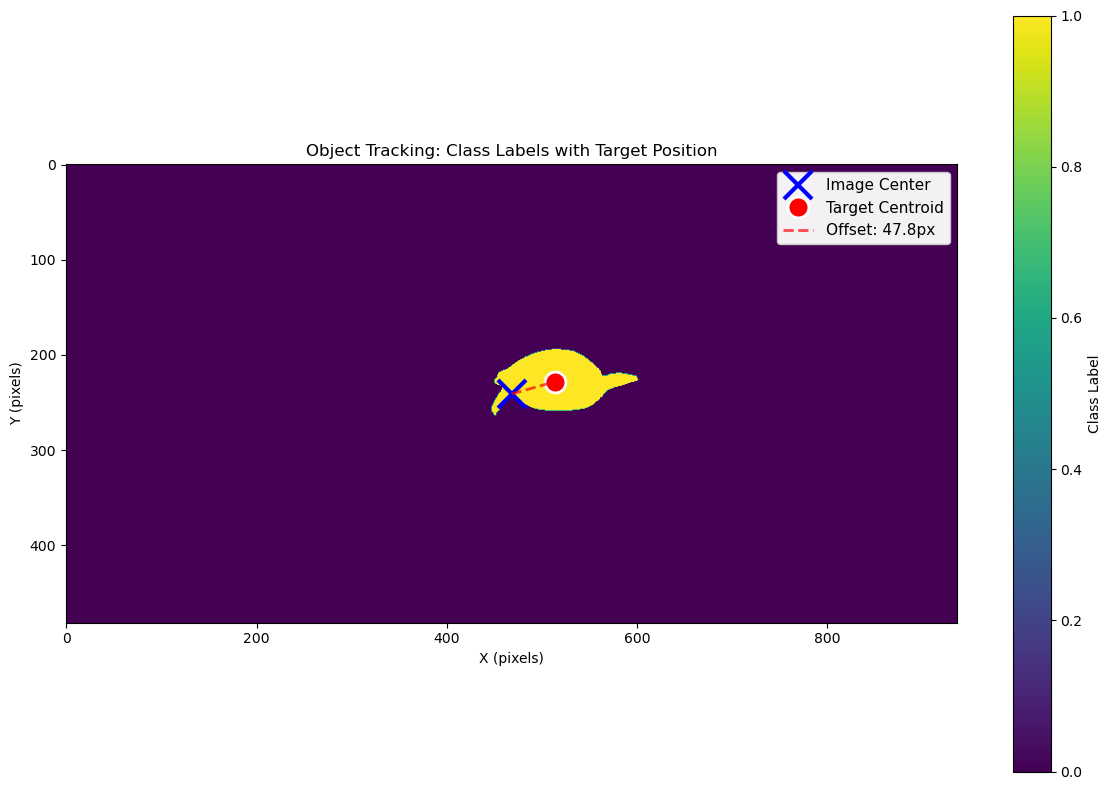

origin: (468, 241)

centroid: (514, 228)

6209
Recovered class labels shape: (482, 937)
Distance from origin: 47.80 pixels



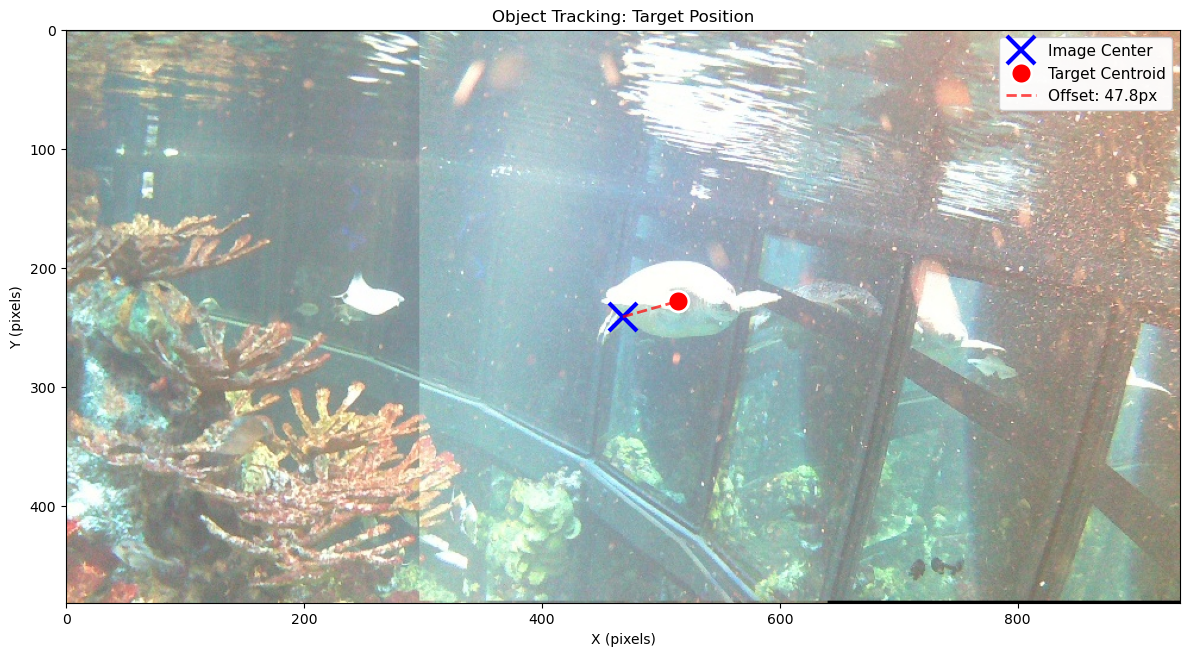

origin: (468, 241)

centroid: (514, 228)

6209
Recovered class labels shape: (482, 937)
Distance from origin: 47.80 pixels



error: OpenCV(4.6.0) ./modules/imgproc/src/contours.cpp:195: error: (-210:Unsupported format or combination of formats) [Start]FindContours supports only CV_8UC1 images when mode != CV_RETR_FLOODFILL otherwise supports CV_32SC1 images only in function 'cvStartFindContours_Impl'


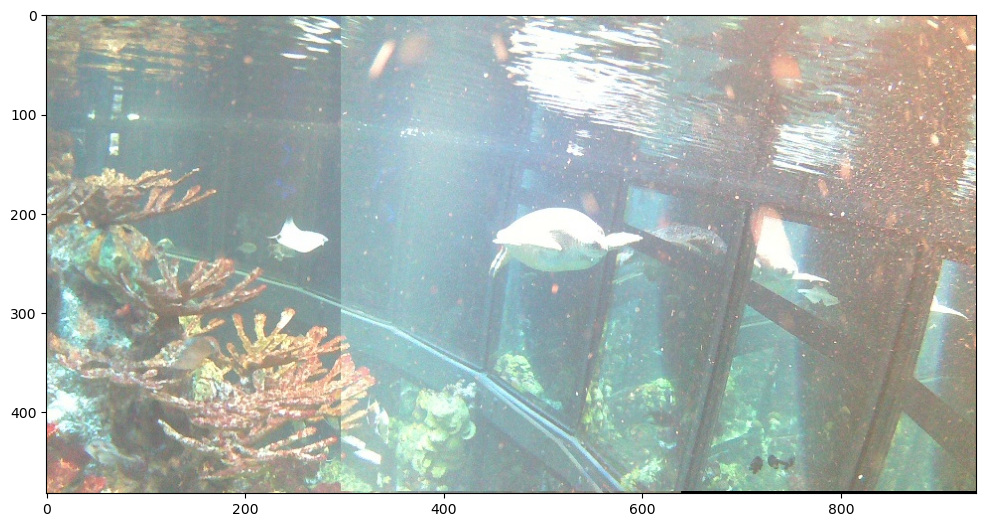

In [ ]:
# Assuming image1.jpg is the overlay and image2.jpg is the original image

dir = '/home/ranger/Downloads/08_19_2025_10_26_45_Turtle_Good/track/'
index = '/1_).jpg'
overlag_path = dir + 'Tracker-result/' + index
og_path = dir + 'Stream_tracking/' + index
image_folder = dir + 'Stream_tracking/'
image_files = glob.glob(os.path.join(image_folder, f"*.jpg"))


centroids = []
image_files.sort(key=natural_sort_key)

overlay_img = plt.imread(overlag_path)
original_img = plt.imread(og_path)



# You need to provide the correct number of labels and alpha used to create the overlay
# Replace these with the actual values
num_of_labels = 2
alpha = 0.5

class_labels = recover_class_labels(overlay_img, original_img, num_of_labels, alpha=alpha)
target_pixels = np.where(class_labels == 1)
centroid_y = int(np.mean(target_pixels[0]))
centroid_x = int(np.mean(target_pixels[1]))
height, width = original_img.shape[:2]
origin_y = height // 2
origin_x = width // 2

print(f"origin: {(origin_x, origin_y)}\n")
print(f"centroid: {(centroid_x, centroid_y)}\n")
print(len(target_pixels))
print("Recovered class labels shape:", class_labels.shape)

print(f"origin: {(origin_x, origin_y)}\n")
print(f"centroid: {(centroid_x, centroid_y)}\n")
print(len(target_pixels[0]))  # Number of pixels
print("Recovered class labels shape:", class_labels.shape)

# Calculate distance
distance = np.sqrt((centroid_x - origin_x)**2 + (centroid_y - origin_y)**2)
print(f"Distance from origin: {distance:.2f} pixels\n")

# Plot the class labels with centroid and origin marked
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(class_labels, cmap='viridis')

# Plot image center (blue X)
ax.plot(origin_x, origin_y, 'bx', markersize=20, 
        markeredgewidth=3, label='Image Center')

# Plot target centroid (red circle)
ax.plot(centroid_x, centroid_y, 'ro', markersize=15, 
        markeredgewidth=2, markeredgecolor='white', label='Target Centroid')

# Draw line connecting them
ax.plot([origin_x, centroid_x], [origin_y, centroid_y], 
        'r--', linewidth=2, alpha=0.7, label=f'Offset: {distance:.1f}px')

plt.colorbar(ax.images[0], label='Class Label')
plt.title("Object Tracking: Class Labels with Target Position")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()


# over og image: 

print(f"origin: {(origin_x, origin_y)}\n")
print(f"centroid: {(centroid_x, centroid_y)}\n")
print(len(target_pixels[0]))  # Number of pixels
print("Recovered class labels shape:", class_labels.shape)

# Calculate distance
distance = np.sqrt((centroid_x - origin_x)**2 + (centroid_y - origin_y)**2)
print(f"Distance from origin: {distance:.2f} pixels\n")

# Plot over the original image
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(original_img)  # Use original_img instead of class_labels

# Plot image center (blue X)
ax.plot(origin_x, origin_y, 'bx', markersize=20, 
        markeredgewidth=3, label='Image Center')

# Plot target centroid (red circle)
ax.plot(centroid_x, centroid_y, 'ro', markersize=15, 
        markeredgewidth=2, markeredgecolor='white', label='Target Centroid')

# Draw line connecting them
ax.plot([origin_x, centroid_x], [origin_y, centroid_y], 
        'r--', linewidth=2, alpha=0.7, label=f'Offset: {distance:.1f}px')

plt.title("Object Tracking: Target Position")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()


print(f"origin: {(origin_x, origin_y)}\n")
print(f"centroid: {(centroid_x, centroid_y)}\n")
print(len(target_pixels[0]))  # Number of pixels
print("Recovered class labels shape:", class_labels.shape)

# Calculate distance
distance = np.sqrt((centroid_x - origin_x)**2 + (centroid_y - origin_y)**2)
print(f"Distance from origin: {distance:.2f} pixels\n")

# Create a masked overlay
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(original_img)

# Create a mask for the target (class == 1)
mask = np.ma.masked_where(class_labels != 1, class_labels)

# Overlay the mask with transparency
# ax.imshow(mask, cmap='viridis', alpha=0.5, vmin=0, vmax=np.max(class_labels))
mask = overlay_img

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw lime green contours
for contour in contours:
    # Convert contour to matplotlib format (swap x,y)
    contour = contour.reshape(-1, 2)
    ax.plot(contour[:, 0], contour[:, 1], color='lime', linewidth=3)
    # Close the contour
    ax.plot([contour[-1, 0], contour[0, 0]], 
            [contour[-1, 1], contour[0, 1]], color='lime', linewidth=3)


# Plot image center (blue X)
ax.plot(origin_x, origin_y, 'bx', markersize=20, 
        markeredgewidth=3, label='Image Center')

# Plot target centroid (red circle)
ax.plot(centroid_x, centroid_y, 'ro', markersize=15, 
        markeredgewidth=2, markeredgecolor='white', label='Target Centroid')

# Draw line connecting them
ax.plot([origin_x, centroid_x], [origin_y, centroid_y], 
        'r--', linewidth=2, alpha=0.7, label=f'Offset: {distance:.1f}px')

plt.title("Object Tracking: Target Position with Segmentation Overlay")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()


from matplotlib.colors import LinearSegmentedColormap

# Create overlay with jet colormap (matches your tracker visualization)
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.imshow(original_img)

# Create colored overlay for target
mask = np.zeros_like(class_labels)
mask[class_labels == 1] = 1
mask_colored = np.ma.masked_where(mask == 0, mask)

ax.imshow(mask_colored, cmap='jet', alpha=0.5, vmin=0, vmax=2)

# Plot markers
ax.plot(origin_x, origin_y, 'bx', markersize=20, 
        markeredgewidth=3, label='Image Center')
ax.plot(centroid_x, centroid_y, 'ro', markersize=15, 
        markeredgewidth=2, markeredgecolor='white', label='Target Centroid')
ax.plot([origin_x, centroid_x], [origin_y, centroid_y], 
        'r--', linewidth=2, alpha=0.7, label=f'Offset: {distance:.1f}px')

plt.title("Object Tracking: Target Position with Segmentation Overlay")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend(loc='upper right', fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()